In [2]:
import re
import warnings
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dateutil import parser as dparser

In [3]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [4]:
EUR_TO_USD = 1.2
DATA_ROOT  = 'data'

def parse_price(s):
    """Convert a messy price string to USD float.
    Handles formats like: '27.00$', '€50¢50', 'USD 45.99', '22$75¢', etc.
    """
    if not isinstance(s, str):
        return None
    s = s.strip()
    if not s:
        return None

    is_euro = '€' in s

    m = re.match(r'^[€]?\s*([\d.]+)\s*[\$€]\s*(\d+)\s*¢', s)
    if m:
        val = float(m.group(1)) + float(m.group(2)) / 100
        if is_euro:
            val *= EUR_TO_USD
        return round(val, 2)

    m = re.match(r'^€\s*([\d.]+)\s*¢\s*(\d+)', s)
    if m:
        val = (float(m.group(1)) + float(m.group(2)) / 100) * EUR_TO_USD
        return round(val, 2)

    num_str = re.sub(r'[€\$¢]|USD|EUR', '', s).strip()
    try:
        val = float(num_str.replace(',', '.'))
    except ValueError:
        return None
    if is_euro:
        val *= EUR_TO_USD
    return round(val, 2)

In [5]:
def parse_timestamp(s):
    """Parse messy timestamp strings into a datetime object.
    Normalises separators (;  ,) before handing off to dateutil.
    """
    if not isinstance(s, str) or not s.strip():
        return pd.NaT
    s2 = re.sub(r'[;,]', ' ', s.strip())
    try:
        return dparser.parse(s2)
    except Exception:
        return pd.NaT

In [6]:
def deduplicate_users(users_df):
    """Group user records that share an email or phone (one field may change).
    Returns a mapping  {original_id -> canonical_id}  (smallest id in group).
    Uses Union-Find for transitive linking.
    """
    parent = {uid: uid for uid in users_df['id']}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            if ra < rb:
                parent[rb] = ra
            else:
                parent[ra] = rb
                
    for _, grp in users_df.groupby('email'):
        ids = grp['id'].tolist()
        for i in range(1, len(ids)):
            union(ids[0], ids[i])
    users_df = users_df.copy()
    users_df['phone_norm'] = users_df['phone'].str.replace(r'\D', '', regex=True)
    for _, grp in users_df.groupby('phone_norm'):
        ids = grp['id'].tolist()
        for i in range(1, len(ids)):
            union(ids[0], ids[i])

    return {uid: find(uid) for uid in users_df['id']}

In [7]:
def author_set(author_str):
    """Return a frozenset of individual author names from a comma-separated string."""
    names = [n.strip() for n in str(author_str).split(',') if n.strip()]
    return frozenset(names)


print('Helpers loaded ✓')

Helpers loaded ✓


## 1. DATA1

In [8]:
folder = f'{DATA_ROOT}/DATA1'

users1   = pd.read_csv(f'{folder}/users.csv')
orders1  = pd.read_parquet(f'{folder}/orders.parquet')
with open(f'{folder}/books.yaml') as f:
    books1 = pd.DataFrame(yaml.safe_load(f)).rename(columns=lambda c: c.lstrip(':'))

print('Shapes:', users1.shape, orders1.shape, books1.shape)
print('Columns:', users1.columns.values, orders1.columns.values, books1.columns.values)

Shapes: (3293, 5) (11237, 7) (753, 6)
Columns: ['id' 'name' 'address' 'phone' 'email'] ['id' 'user_id' 'book_id' 'quantity' 'unit_price' 'timestamp' 'shipping'] ['id' 'title' 'author' 'genre' 'publisher' 'year']


### Preprocessing users1

In [9]:
users1 = users1.drop_duplicates()
users1['id'] = users1['id'].astype(int)
users1['name']    = users1['name'].str.strip()
users1['email']   = users1['email'].str.strip().str.lower()
users1['phone']   = users1['phone'].str.strip()
users1['address'] = users1['address'].str.strip()

print(users1.head(3).to_string())

      id               name                                                    address           phone                         email
0  44533        Hoyt Carter          Apt. 300 8604 Ashlyn Wells, Effertzstad, ID 02997  (462) 385-4294  mckinley.rowe@harber.example
1  46128        Marco Kulas  Apt. 538 816 Bechtelar Ferry, Lincolnhaven, KS 47205-5856    913.466.4487  francisco@murray-cronin.test
2  46407  Denny Goyette LLD       Apt. 174 39450 Mohr Rapids, Port Neomistad, AL 80283  (801) 970-3335       marguerita@wuckert.test


### Preprocessing orders1

In [10]:
orders1 = orders1.drop_duplicates()

orders1['timestamp'] = orders1['timestamp'].apply(parse_timestamp)
orders1 = orders1.dropna(subset=['timestamp'])  
orders1['date']  = orders1['timestamp'].dt.date
orders1['year']  = orders1['timestamp'].dt.year
orders1['month'] = orders1['timestamp'].dt.month
orders1['day']   = orders1['timestamp'].dt.day

orders1['unit_price_usd'] = orders1['unit_price'].apply(parse_price)
bad_price = orders1['unit_price_usd'].isna().sum()
if bad_price:
    print(f'  Dropping {bad_price} rows with unparsable unit_price')
    orders1 = orders1.dropna(subset=['unit_price_usd'])

orders1['paid_price'] = (orders1['quantity'] * orders1['unit_price_usd']).round(2)

orders1['id']       = orders1['id'].astype(int)
orders1['user_id']  = orders1['user_id'].astype(int)
orders1['book_id']  = orders1['book_id'].astype(int)
orders1['quantity'] = orders1['quantity'].astype(int)

print(orders1[['id','user_id','book_id','quantity','unit_price','unit_price_usd','paid_price','date','year','month','day']].head(10).to_string())
orders1.shape

      id  user_id  book_id  quantity unit_price  unit_price_usd  paid_price        date  year  month  day
0  71389    47288    18976         2     27.00$           27.00       54.00  2024-10-01  2024     10    1
1  66343    47049    19403         1     €50¢50           60.60       60.60  2024-10-19  2024     10   19
2  72606    46685    19500         1  USD 45.99           45.99       45.99  2025-07-02  2025      7    2
3  68462    45336    18992         1    € 71.00           85.20       85.20  2025-10-20  2025     10   20
4  72691    45311    19388         1    52.25 $           52.25       52.25  2024-08-28  2024      8   28
5  68274    45939    19251         3     22$75¢           22.75       68.25  2024-07-01  2024      7    1
6  66248    45486    19550         1     35 USD           35.00       35.00  2025-02-07  2025      2    7
7  64098    46656    19558         1  33.00 USD           33.00       33.00  2024-10-30  2024     10   30
8  73454    44440    18990         1   44.75US

(11237, 13)

### Preprocessing books1

In [11]:
books1 = books1.drop_duplicates()
books1['id']   = books1['id'].astype(int)
books1['year'] = pd.to_numeric(books1['year'], errors='coerce')
books1['title']  = books1['title'].str.strip()
books1['author'] = books1['author'].str.strip()

print(books1.head(3).to_string())

      id                         title                                            author                    genre              publisher    year
0  19199  The Yellow Meads of Asphodel                                     Carolyne West                  Classic  Mainstream Publishing  2009.0
1  19398         From Here to Eternity  Rep. Heath Stiedemann, Gino Welch, Haydee Larson              Short story          Vintage Books  2001.0
2  19483               Eyeless in Gaza                                    Vannessa Price  Biography/Autobiography         Pavilion Books  1886.0


### 1.1 Daily Revenue & Top 5 Days

In [12]:
daily_rev1 = (
    orders1.groupby('date')['paid_price']
    .sum()
    .reset_index()
    .rename(columns={'paid_price': 'revenue'})
    .sort_values('revenue', ascending=False)
)

top5_1 = daily_rev1.head(5).copy()
top5_1['date_str'] = top5_1['date'].astype(str)
top5_1['revenue']  = top5_1['revenue'].round(2)

print('\n📅 Top 5 Days by Revenue – DATA1')
print(top5_1[['date_str','revenue']].to_string(index=False))


📅 Top 5 Days by Revenue – DATA1
  date_str  revenue
2024-12-05 42218.64
2025-03-29 41930.30
2024-11-11 40265.38
2024-09-04 40260.38
2025-03-14 38376.11


### 1.2 Unique Users (after reconciliation)

In [13]:
id_to_canonical1 = deduplicate_users(users1)
n_unique_users1  = len(set(id_to_canonical1.values()))

print(f'Raw user records : {len(users1)}')
print(f'Unique real users: {n_unique_users1}')

Raw user records : 3293
Unique real users: 3115


### 1.3 Unique Author Sets

In [14]:
books1['author_set'] = books1['author'].apply(author_set)
unique_author_sets1  = books1['author_set'].nunique()

print(f'Unique author sets (DATA1): {unique_author_sets1}')
print('Sample sets:')
for s in books1['author_set'].unique()[:5]:
    print(' ', sorted(s))

Unique author sets (DATA1): 325
Sample sets:
  ['Carolyne West']
  ['Gino Welch', 'Haydee Larson', 'Rep. Heath Stiedemann']
  ['Vannessa Price']
  ['Miss Yong Wyman']
  ['Travis Moore']


### 1.4 Most Popular Author / Author Set (by books sold)

In [15]:
merged1 = orders1.merge(books1[['id','author','author_set']], left_on='book_id', right_on='id', how='left')

author_sales1 = (
    merged1.groupby('author_set')['quantity']
    .sum()
    .reset_index()
    .sort_values('quantity', ascending=False)
)

top_author_set1    = author_sales1.iloc[0]['author_set']
top_author_qty1    = author_sales1.iloc[0]['quantity']
top_author_label1  = ', '.join(sorted(top_author_set1))

print(f'Most popular author(s): {top_author_label1}')
print(f'Total books sold      : {top_author_qty1}')

Most popular author(s): Arlinda Huel
Total books sold      : 201


### 1.5 Top Customer by Total Spending

In [16]:
orders1['canonical_id'] = orders1['user_id'].map(id_to_canonical1)

spending1 = (
    orders1.groupby('canonical_id')['paid_price']
    .sum()
    .reset_index()
    .sort_values('paid_price', ascending=False)
)

top_canonical1 = spending1.iloc[0]['canonical_id']
top_spending1  = spending1.iloc[0]['paid_price']

top_ids1 = [uid for uid, can in id_to_canonical1.items() if can == top_canonical1]

print(f'Top customer canonical id : {top_canonical1}')
print(f'Total spending (USD)      : ${top_spending1:,.2f}')
print(f'All associated user_ids   : {sorted(top_ids1)}')

Top customer canonical id : 44650.0
Total spending (USD)      : $40,279.25
All associated user_ids   : [44650]


### 1.6 Daily Revenue Line Chart

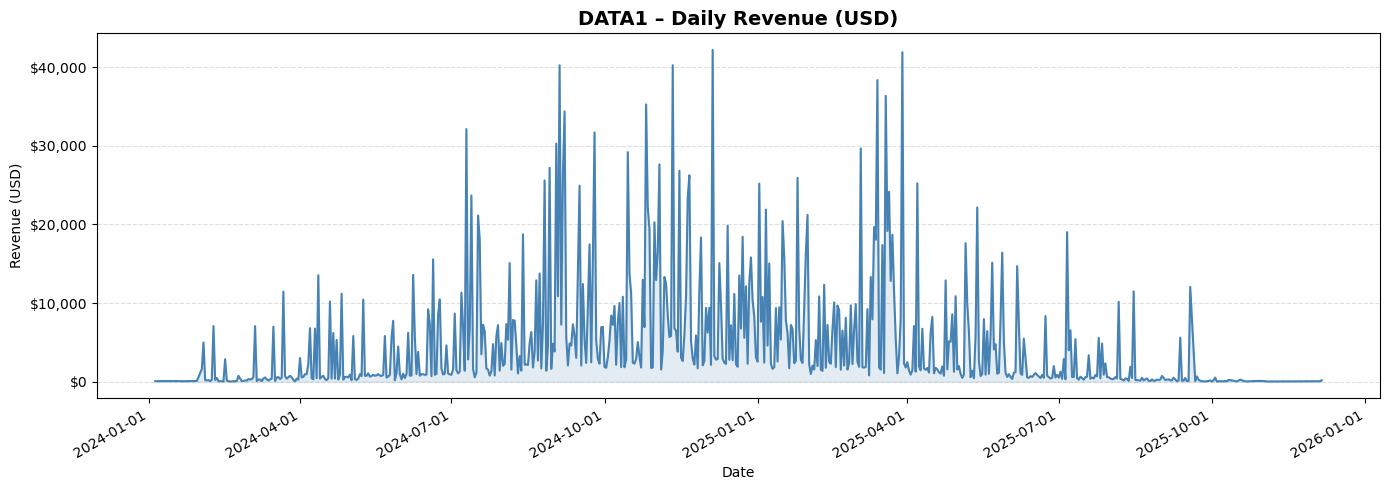

Chart saved as daily_revenue_DATA1.png


In [17]:
chart_data1 = daily_rev1.sort_values('date').copy()
chart_data1['date'] = pd.to_datetime(chart_data1['date'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(chart_data1['date'], chart_data1['revenue'], linewidth=1.5, color='steelblue')
ax.fill_between(chart_data1['date'], chart_data1['revenue'], alpha=0.15, color='steelblue')
ax.set_title('DATA1 – Daily Revenue (USD)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=30, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('daily_revenue_DATA1.png', dpi=150)
plt.show()
print('Chart saved as daily_revenue_DATA1.png')

---
## 2. DATA2

In [18]:
folder = f'{DATA_ROOT}/DATA2'

users2   = pd.read_csv(f'{folder}/users.csv')
orders2  = pd.read_parquet(f'{folder}/orders.parquet')
with open(f'{folder}/books.yaml') as f:
    books2 = pd.DataFrame(yaml.safe_load(f)).rename(columns=lambda c: c.lstrip(':'))

print('Shapes:', users2.shape, orders2.shape, books2.shape)

Shapes: (2810, 5) (9850, 7) (741, 6)


In [19]:
users2 = users2.drop_duplicates()
users2['id']      = users2['id'].astype(int)
users2['name']    = users2['name'].str.strip()
users2['email']   = users2['email'].str.strip().str.lower()
users2['phone']   = users2['phone'].str.strip()
users2['address'] = users2['address'].str.strip()

orders2 = orders2.drop_duplicates()
orders2['timestamp']      = orders2['timestamp'].apply(parse_timestamp)
orders2 = orders2.dropna(subset=['timestamp'])
orders2['date']  = orders2['timestamp'].dt.date
orders2['year']  = orders2['timestamp'].dt.year
orders2['month'] = orders2['timestamp'].dt.month
orders2['day']   = orders2['timestamp'].dt.day
orders2['unit_price_usd'] = orders2['unit_price'].apply(parse_price)
orders2 = orders2.dropna(subset=['unit_price_usd'])
orders2['paid_price'] = (orders2['quantity'] * orders2['unit_price_usd']).round(2)
orders2[['id','user_id','book_id','quantity']] = (
    orders2[['id','user_id','book_id','quantity']].astype(int)
)

books2 = books2.drop_duplicates()
books2['id']   = books2['id'].astype(int)
books2['year'] = pd.to_numeric(books2['year'], errors='coerce')
books2['title']  = books2['title'].str.strip()
books2['author'] = books2['author'].str.strip()
books2['author_set'] = books2['author'].apply(author_set)

print('DATA2 cleaned ✓')

DATA2 cleaned ✓


In [20]:
daily_rev2 = (
    orders2.groupby('date')['paid_price'].sum()
    .reset_index().rename(columns={'paid_price':'revenue'})
    .sort_values('revenue', ascending=False)
)
top5_2 = daily_rev2.head(5).copy()
top5_2['date_str'] = top5_2['date'].astype(str)
print('\n📅 Top 5 Days by Revenue – DATA2')
print(top5_2[['date_str','revenue']].to_string(index=False))

id_to_canonical2 = deduplicate_users(users2)
n_unique_users2  = len(set(id_to_canonical2.values()))
print(f'\nUnique real users (DATA2): {n_unique_users2}')

unique_author_sets2 = books2['author_set'].nunique()
print(f'Unique author sets (DATA2): {unique_author_sets2}')

merged2 = orders2.merge(books2[['id','author','author_set']], left_on='book_id', right_on='id', how='left')
author_sales2 = (
    merged2.groupby('author_set')['quantity'].sum()
    .reset_index().sort_values('quantity', ascending=False)
)
top_author_set2   = author_sales2.iloc[0]['author_set']
top_author_label2 = ', '.join(sorted(top_author_set2))
print(f'Most popular author(s) (DATA2): {top_author_label2}')

orders2['canonical_id'] = orders2['user_id'].map(id_to_canonical2)
spending2 = (
    orders2.groupby('canonical_id')['paid_price'].sum()
    .reset_index().sort_values('paid_price', ascending=False)
)
top_canonical2 = spending2.iloc[0]['canonical_id']
top_ids2 = sorted([uid for uid, can in id_to_canonical2.items() if can == top_canonical2])
print(f'Top customer IDs (DATA2): {top_ids2}')


📅 Top 5 Days by Revenue – DATA2
  date_str  revenue
2025-09-02 33683.00
2024-07-09 33392.59
2025-02-01 32755.20
2024-11-03 32338.30
2025-01-25 31895.66

Unique real users (DATA2): 2663
Unique author sets (DATA2): 293
Most popular author(s) (DATA2): Hershel Treutel, Miss Modesto Denesik, Sen. Trula Bosco
Top customer IDs (DATA2): [54419]


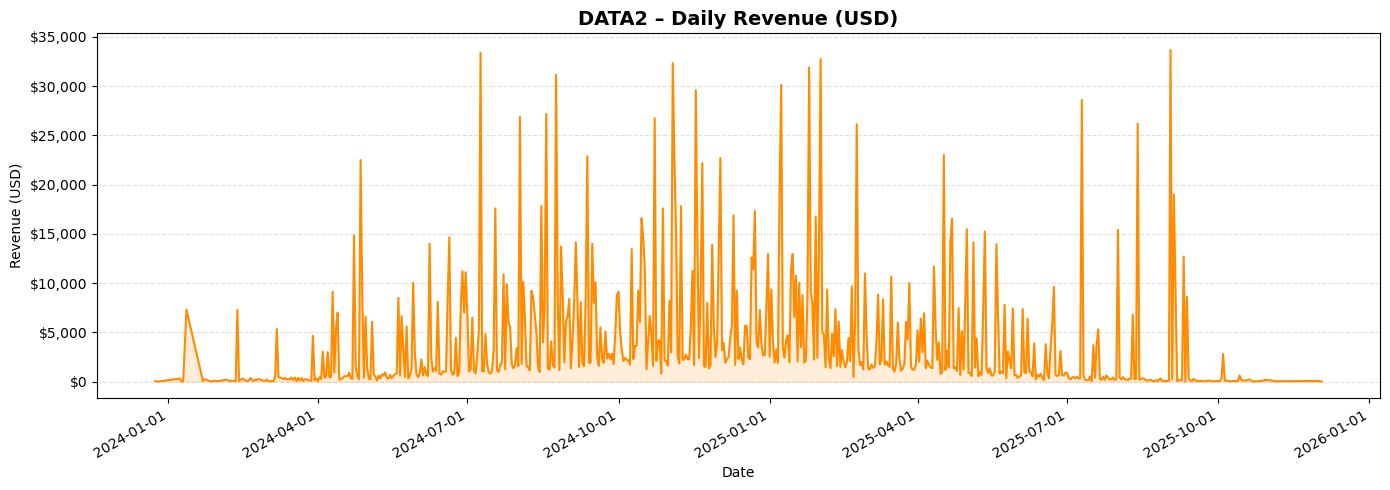

Chart saved as daily_revenue_DATA2.png


In [21]:
chart_data2 = daily_rev2.sort_values('date').copy()
chart_data2['date'] = pd.to_datetime(chart_data2['date'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(chart_data2['date'], chart_data2['revenue'], linewidth=1.5, color='darkorange')
ax.fill_between(chart_data2['date'], chart_data2['revenue'], alpha=0.15, color='darkorange')
ax.set_title('DATA2 – Daily Revenue (USD)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=30, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('daily_revenue_DATA2.png', dpi=150)
plt.show()
print('Chart saved as daily_revenue_DATA2.png')

---
## 3. DATA3

In [22]:
folder = f'{DATA_ROOT}/DATA3'

users3   = pd.read_csv(f'{folder}/users.csv')
orders3  = pd.read_parquet(f'{folder}/orders.parquet')
with open(f'{folder}/books.yaml') as f:
    books3 = pd.DataFrame(yaml.safe_load(f)).rename(columns=lambda c: c.lstrip(':'))

print('Shapes:', users3.shape, orders3.shape, books3.shape)

Shapes: (3466, 5) (8933, 7) (762, 6)


In [23]:
users3 = users3.drop_duplicates()
users3['id']      = users3['id'].astype(int)
users3['name']    = users3['name'].str.strip()
users3['email']   = users3['email'].str.strip().str.lower()
users3['phone']   = users3['phone'].str.strip()
users3['address'] = users3['address'].str.strip()

orders3 = orders3.drop_duplicates()
orders3['timestamp']      = orders3['timestamp'].apply(parse_timestamp)
orders3 = orders3.dropna(subset=['timestamp'])
orders3['date']  = orders3['timestamp'].dt.date
orders3['year']  = orders3['timestamp'].dt.year
orders3['month'] = orders3['timestamp'].dt.month
orders3['day']   = orders3['timestamp'].dt.day
orders3['unit_price_usd'] = orders3['unit_price'].apply(parse_price)
orders3 = orders3.dropna(subset=['unit_price_usd'])
orders3['paid_price'] = (orders3['quantity'] * orders3['unit_price_usd']).round(2)
orders3[['id','user_id','book_id','quantity']] = (
    orders3[['id','user_id','book_id','quantity']].astype(int)
)

books3 = books3.drop_duplicates()
books3['id']   = books3['id'].astype(int)
books3['year'] = pd.to_numeric(books3['year'], errors='coerce')
books3['title']  = books3['title'].str.strip()
books3['author'] = books3['author'].str.strip()
books3['author_set'] = books3['author'].apply(author_set)

print('DATA3 cleaned ✓')

DATA3 cleaned ✓


In [24]:
daily_rev3 = (
    orders3.groupby('date')['paid_price'].sum()
    .reset_index().rename(columns={'paid_price':'revenue'})
    .sort_values('revenue', ascending=False)
)
top5_3 = daily_rev3.head(5).copy()
top5_3['date_str'] = top5_3['date'].astype(str)
print('\n📅 Top 5 Days by Revenue – DATA3')
print(top5_3[['date_str','revenue']].to_string(index=False))

id_to_canonical3 = deduplicate_users(users3)
n_unique_users3  = len(set(id_to_canonical3.values()))
print(f'\nUnique real users (DATA3): {n_unique_users3}')

unique_author_sets3 = books3['author_set'].nunique()
print(f'Unique author sets (DATA3): {unique_author_sets3}')

merged3 = orders3.merge(books3[['id','author','author_set']], left_on='book_id', right_on='id', how='left')
author_sales3 = (
    merged3.groupby('author_set')['quantity'].sum()
    .reset_index().sort_values('quantity', ascending=False)
)
top_author_set3   = author_sales3.iloc[0]['author_set']
top_author_label3 = ', '.join(sorted(top_author_set3))
print(f'Most popular author(s) (DATA3): {top_author_label3}')

orders3['canonical_id'] = orders3['user_id'].map(id_to_canonical3)
spending3 = (
    orders3.groupby('canonical_id')['paid_price'].sum()
    .reset_index().sort_values('paid_price', ascending=False)
)
top_canonical3 = spending3.iloc[0]['canonical_id']
top_ids3 = sorted([uid for uid, can in id_to_canonical3.items() if can == top_canonical3])
print(f'Top customer IDs (DATA3): {top_ids3}')


📅 Top 5 Days by Revenue – DATA3
  date_str  revenue
2025-01-29 47343.39
2024-09-16 36316.19
2024-12-09 35453.63
2025-01-16 33311.91
2024-11-26 32751.86

Unique real users (DATA3): 3290
Unique author sets (DATA3): 268
Most popular author(s) (DATA3): Coy Streich, Keeley Hand, Lela Emard
Top customer IDs (DATA3): [50855]


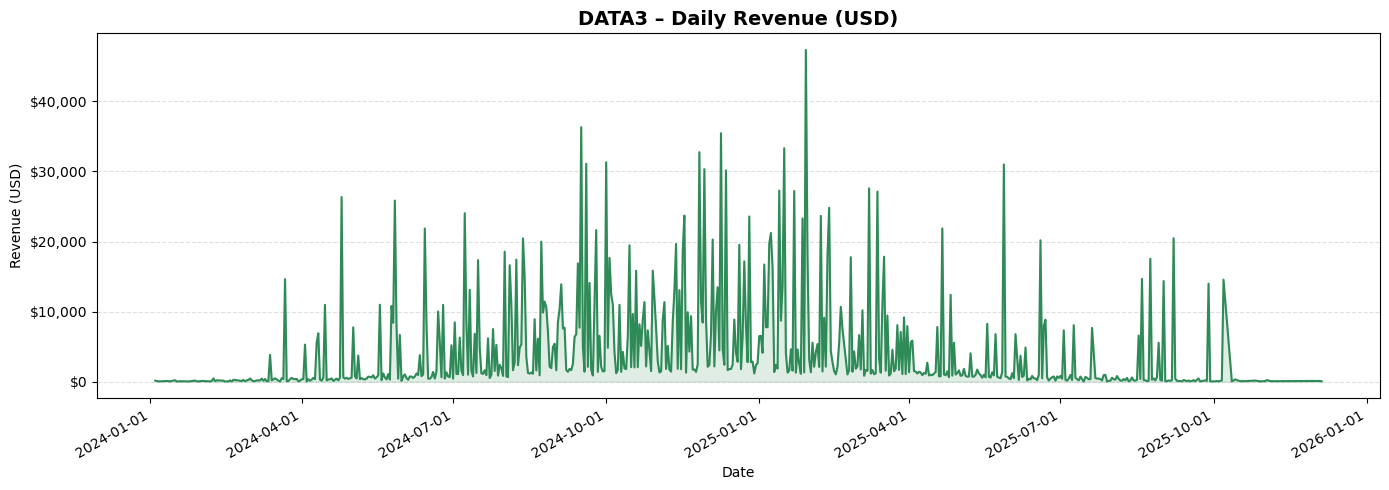

Chart saved as daily_revenue_DATA3.png


In [25]:
chart_data3 = daily_rev3.sort_values('date').copy()
chart_data3['date'] = pd.to_datetime(chart_data3['date'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(chart_data3['date'], chart_data3['revenue'], linewidth=1.5, color='seagreen')
ax.fill_between(chart_data3['date'], chart_data3['revenue'], alpha=0.15, color='seagreen')
ax.set_title('DATA3 – Daily Revenue (USD)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=30, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('daily_revenue_DATA3.png', dpi=150)
plt.show()
print('Chart saved as daily_revenue_DATA3.png')

---
## 4. Summary Table – All Three Datasets

In [26]:
summary = pd.DataFrame({
    'Dataset': ['DATA1', 'DATA2', 'DATA3'],
    'Unique Users': [n_unique_users1, n_unique_users2, n_unique_users3],
    'Unique Author Sets': [unique_author_sets1, unique_author_sets2, unique_author_sets3],
    'Top Author(s)': [top_author_label1, top_author_label2, top_author_label3],
    'Top Buyer IDs': [str(sorted(top_ids1)), str(top_ids2), str(top_ids3)],
})
print(summary.to_string(index=False))

Dataset  Unique Users  Unique Author Sets                                           Top Author(s) Top Buyer IDs
  DATA1          3115                 325                                            Arlinda Huel       [44650]
  DATA2          2663                 293 Hershel Treutel, Miss Modesto Denesik, Sen. Trula Bosco       [54419]
  DATA3          3290                 268                    Coy Streich, Keeley Hand, Lela Emard       [50855]


In [27]:
for label, top5 in [('DATA1', top5_1), ('DATA2', top5_2), ('DATA3', top5_3)]:
    print(f'\n🏆 {label} – Top 5 Revenue Days')
    for _, row in top5.iterrows():
        print(f"  {row['date_str']}   ${row['revenue']:>10,.2f}")


🏆 DATA1 – Top 5 Revenue Days
  2024-12-05   $ 42,218.64
  2025-03-29   $ 41,930.30
  2024-11-11   $ 40,265.38
  2024-09-04   $ 40,260.38
  2025-03-14   $ 38,376.11

🏆 DATA2 – Top 5 Revenue Days
  2025-09-02   $ 33,683.00
  2024-07-09   $ 33,392.59
  2025-02-01   $ 32,755.20
  2024-11-03   $ 32,338.30
  2025-01-25   $ 31,895.66

🏆 DATA3 – Top 5 Revenue Days
  2025-01-29   $ 47,343.39
  2024-09-16   $ 36,316.19
  2024-12-09   $ 35,453.63
  2025-01-16   $ 33,311.91
  2024-11-26   $ 32,751.86
